# 077: HP Alphabet Sweep — Sensitivity Curves, Top Families & Summary

Loads AUC cache from 075. Generates full sensitivity / precision-recall curves, top-detected SCOPe families, unclassified-family enrichment, coverage-aware AUC, and a complete summary table.

**Depends on:** 075 (AUC cache parquet)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import gc
import sys
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
from scipy.stats import chi2_contingency

sys.path.append(str(Path.cwd()))
from scope_kmerseek_utils import (
    EVAL_USECOLS, TEA_DIR, SCOPE_CLASS_DESCRIPTIONS,
    load_baselines, add_composite_scores_scope, recompute_bonferroni,
    eval_tsv_to_rocx, rocx_restrict, sensitivity_stats,
)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 120

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
SWEEP_DIR  = Path.home() / 'data/scope/results-hp-alphabet-sweep'
FIG_PREFIX = '../figures/077'
Path('../figures').mkdir(exist_ok=True)

# ---------------------------------------------------------------------------
# Alphabet definitions (same order as Nextflow pipeline)
# ---------------------------------------------------------------------------
NAMED_LABELS = [
    'hp_thomas_dill',
    'hp_kyte_doolittle',
    'hp_thomas_dill_no_c',
    'hp_lehninger_plus_c',
    'hp_pbotc_1st_ed',
]
SEED_LABELS = [f'hp_shuffled_control_{i}' for i in range(1, 11)]
ALL_LABELS  = NAMED_LABELS + SEED_LABELS

KSIZES = list(range(20, 41))   # pipeline ran k=20–40

BONF_THRESHOLD = 0.05
NQUERY_MINS    = [200, 150, 100]  # coverage thresholds for best-k search

# Named-alphabet colours (shuffled controls will use grey tones)
NAMED_COLORS = {
    'hp_thomas_dill':       'tomato',
    'hp_kyte_doolittle':    'steelblue',
    'hp_thomas_dill_no_c':  'seagreen',
    'hp_lehninger_plus_c':  'navy',
    'hp_pbotc_1st_ed':      'mediumpurple',
    'hp_shuffled_control':  'saddlebrown',
}

print('SWEEP_DIR:', SWEEP_DIR)
print('N alphabets:', len(ALL_LABELS))
print('K-sizes:', KSIZES[0], '–', KSIZES[-1])

SWEEP_DIR: /Users/olga/data/scope/results-hp-alphabet-sweep
N alphabets: 15
K-sizes: 20 – 40


In [3]:
def eval_path(label: str, k: int) -> Path:
    gz = SWEEP_DIR / f'scope_eval.{label}.k{k}.tsv.gz'
    return gz if gz.exists() else SWEEP_DIR / f'scope_eval.{label}.k{k}.tsv'


def has_data(label: str, k: int) -> bool:
    p = eval_path(label, k)
    return p.exists() and p.stat().st_size > 0


available = {(lbl, k): has_data(lbl, k) for lbl in ALL_LABELS for k in KSIZES}
n_avail   = sum(available.values())
n_total   = len(available)

print(f'Available eval files: {n_avail} / {n_total}')
if n_avail == 0:
    print()
    print('⚠️  No eval files have data yet.')
    print('   The pipeline ran but kmerseek search wrote 0 rows to its output CSV.')
    print('   Check the search logs in SWEEP_DIR for details.')
    print('   Re-run the pipeline after fixing the kmerseek search output bug.')
    print()
    # Show example log to confirm matches were found
    example_log = SWEEP_DIR / 'scope40.hp_thomas_dill.k25.search.log'
    if example_log.exists():
        print(f'Example log ({example_log.name}):')
        for line in example_log.read_text().splitlines()[-8:]:
            print(' ', line)
else:
    by_label = {lbl: sum(available[(lbl, k)] for k in KSIZES) for lbl in ALL_LABELS}
    for lbl, n in sorted(by_label.items(), key=lambda x: -x[1]):
        print(f'  {lbl:<35s}: {n}/{len(KSIZES)} k-sizes')

Available eval files: 315 / 315
  hp_thomas_dill                     : 21/21 k-sizes
  hp_kyte_doolittle                  : 21/21 k-sizes
  hp_thomas_dill_no_c                : 21/21 k-sizes
  hp_lehninger_plus_c                : 21/21 k-sizes
  hp_pbotc_1st_ed                    : 21/21 k-sizes
  hp_shuffled_control_1              : 21/21 k-sizes
  hp_shuffled_control_2              : 21/21 k-sizes
  hp_shuffled_control_3              : 21/21 k-sizes
  hp_shuffled_control_4              : 21/21 k-sizes
  hp_shuffled_control_5              : 21/21 k-sizes
  hp_shuffled_control_6              : 21/21 k-sizes
  hp_shuffled_control_7              : 21/21 k-sizes
  hp_shuffled_control_8              : 21/21 k-sizes
  hp_shuffled_control_9              : 21/21 k-sizes
  hp_shuffled_control_10             : 21/21 k-sizes


In [4]:
foldseek, tea_all = load_baselines(TEA_DIR)
ref_queries = set(foldseek['NAME'].to_list())

_, _, fs_fam  = sensitivity_stats(foldseek, 'FAM')
_, _, fs_sfam = sensitivity_stats(foldseek, 'SFAM')
_, _, fs_fold = sensitivity_stats(foldseek, 'FOLD')
_, _, tea_fam  = sensitivity_stats(tea_all,  'FAM')
_, _, tea_sfam = sensitivity_stats(tea_all,  'SFAM')
_, _, tea_fold = sensitivity_stats(tea_all,  'FOLD')

print(f'FoldSeek: {foldseek["NAME"].n_unique():,} queries  FAM={fs_fam:.4f}  SFAM={fs_sfam:.4f}  FOLD={fs_fold:.4f}')
print(f'TEA:      {tea_all["NAME"].n_unique():,} queries  FAM={tea_fam:.4f}  SFAM={tea_sfam:.4f}  FOLD={tea_fold:.4f}')
print(f'Benchmarkable query set: {len(ref_queries):,}')

FoldSeek: 5,713 queries  FAM=0.8169  SFAM=0.5743  FOLD=0.1017
TEA:      5,737 queries  FAM=0.8020  SFAM=0.5804  FOLD=0.0868
Benchmarkable query set: 5,713


In [5]:
def load_eval_alphabet(
    label: str, k: int, columns=None
) -> pl.DataFrame:
    """Load scope_eval file for a given alphabet label and k-size."""
    path = eval_path(label, k)
    if not path.exists():
        raise FileNotFoundError(f'Missing: {path}')
    if path.stat().st_size == 0:
        raise FileNotFoundError(f'Empty: {path}')
    df = pl.read_csv(path, separator='\t')
    if columns is not None:
        df = df.select([c for c in columns if c in df.columns])
    return df

In [6]:
CACHE_PATH = SWEEP_DIR / 'auc_sweep_bonf_jaccard.parquet'
FORCE_RECOMPUTE = False

if not FORCE_RECOMPUTE and CACHE_PATH.exists():
    auc_df = pl.read_parquet(CACHE_PATH)
    print(f'Loaded cached AUC sweep: {len(auc_df):,} rows')
else:
    rows = []
    for label in ALL_LABELS:
        print(f'{label}:', end=' ', flush=True)
        for k in KSIZES:
            try:
                ev = load_eval_alphabet(label, k, columns=EVAL_USECOLS)
            except FileNotFoundError:
                print('_', end='', flush=True)
                continue
            ev = add_composite_scores_scope(ev)
            ev = recompute_bonferroni(ev)
            ev_filt = ev.filter(pl.col('bonferroni_correct') < BONF_THRESHOLD)

            rocx   = eval_tsv_to_rocx(ev_filt, score_col='jaccard', ascending=False,
                                       exclude_gray_zone=True)
            rocx_r = rocx.filter(pl.col('NAME').is_in(ref_queries))

            def _aucs(r, level):
                return sensitivity_stats(r, level)[2]

            rows.append(dict(
                label=label, ksize=k,
                n_queries_all=rocx['NAME'].n_unique(),
                n_queries_ref=rocx_r['NAME'].n_unique(),
                auc_fam_all =round(_aucs(rocx,   'FAM'),  5),
                auc_sfam_all=round(_aucs(rocx,   'SFAM'), 5),
                auc_fold_all=round(_aucs(rocx,   'FOLD'), 5),
                auc_fam_ref =round(_aucs(rocx_r, 'FAM'),  5),
                auc_sfam_ref=round(_aucs(rocx_r, 'SFAM'), 5),
                auc_fold_ref=round(_aucs(rocx_r, 'FOLD'), 5),
            ))
            print('.', end='', flush=True)
            del ev, ev_filt, rocx, rocx_r; gc.collect()
        print()

    if rows:
        auc_df = pl.DataFrame(rows)
        auc_df.write_parquet(CACHE_PATH)
        print(f'Saved {len(auc_df):,} rows → {CACHE_PATH.name}')
    else:
        print('No data available — auc_df is empty (pipeline results missing)')
        auc_df = pl.DataFrame(schema={
            'label': pl.Utf8, 'ksize': pl.Int64,
            'n_queries_all': pl.Int64, 'n_queries_ref': pl.Int64,
            'auc_fam_all': pl.Float64, 'auc_sfam_all': pl.Float64, 'auc_fold_all': pl.Float64,
            'auc_fam_ref': pl.Float64, 'auc_sfam_ref': pl.Float64, 'auc_fold_ref': pl.Float64,
        })

Loaded cached AUC sweep: 336 rows


In [7]:
def best_ksize_for_label(auc_df, label, nquery_min=None, level_col='auc_fam_ref'):
    """Return best k-size row for a given alphabet and coverage threshold."""
    sub = auc_df.filter(pl.col('label') == label)
    if nquery_min is not None:
        sub = sub.filter(pl.col('n_queries_ref') >= nquery_min)
    if sub.height == 0:
        return None
    return sub.sort(level_col, descending=True).row(0, named=True)


if auc_df.height > 0:
    print(f'=== Best k-sizes per alphabet (Bonferroni<{BONF_THRESHOLD} + Jaccard, excl. gray zone) ===\n')
    header = f'{"Alphabet":<35} {"Overall":>10} {"n≥200":>10} {"n≥150(≈1%)":>12} {"n≥100":>10}'
    print(header)
    print('-' * len(header))

    best_ks = {}  # label → best (overall) row
    for label in ALL_LABELS:
        best_overall = best_ksize_for_label(auc_df, label, nquery_min=None)
        best_200     = best_ksize_for_label(auc_df, label, nquery_min=200)
        best_150     = best_ksize_for_label(auc_df, label, nquery_min=150)
        best_100     = best_ksize_for_label(auc_df, label, nquery_min=100)

        def fmt(row):
            if row is None:
                return '   —   '
            return f'k={row["ksize"]:2d}(n={row["n_queries_ref"]:3d})'

        print(f'{label:<35} {fmt(best_overall):>10} {fmt(best_200):>10} {fmt(best_150):>10} {fmt(best_100):>10}')
        best_ks[label] = best_overall
else:
    print('No data — skipping best-k summary.')
    best_ks = {lbl: None for lbl in ALL_LABELS}

=== Best k-sizes per alphabet (Bonferroni<0.05 + Jaccard, excl. gray zone) ===

Alphabet                               Overall      n≥200   n≥150(≈1%)      n≥100
---------------------------------------------------------------------------------
hp_thomas_dill                      k=20(n=843) k=20(n=843) k=20(n=843) k=20(n=843)
hp_kyte_doolittle                   k=20(n=707) k=20(n=707) k=20(n=707) k=20(n=707)
hp_thomas_dill_no_c                 k=20(n=787) k=20(n=787) k=20(n=787) k=20(n=787)
hp_lehninger_plus_c                 k=20(n=520) k=20(n=520) k=20(n=520) k=20(n=520)
hp_pbotc_1st_ed                     k=20(n=693) k=20(n=693) k=20(n=693) k=20(n=693)
hp_shuffled_control_1               k=20(n= 56)       —          —          —   
hp_shuffled_control_2               k=22(n= 67)       —          —    k=20(n=149)


hp_shuffled_control_3               k=20(n= 79)       —          —          —   
hp_shuffled_control_4               k=23(n= 87)       —    k=20(n=170) k=22(n=104)
hp_shuffled_control_5               k=20(n= 83)       —          —          —   
hp_shuffled_control_6               k=20(n= 71)       —          —          —   
hp_shuffled_control_7               k=20(n= 66)       —          —          —   
hp_shuffled_control_8               k=20(n= 83)       —          —          —   
hp_shuffled_control_9               k=21(n= 89)       —          —    k=20(n=120)
hp_shuffled_control_10              k=20(n=542) k=20(n=542) k=20(n=542) k=20(n=542)


In [8]:
# Build cls_to_queries from ALL 15,177 SCOPe-40 domains (not just FoldSeek benchmark)
SCOPE_DOMAINS_PATH = Path.home() / 'data/scope/results-scope-pvalue-benchmark/scope_domains.tsv'
scope_domains = pl.read_csv(SCOPE_DOMAINS_PATH, separator='\t')

cls_to_queries = defaultdict(set)
for domain_id, cls in scope_domains.select(['domain_id', 'scop_class']).iter_rows():
    cls_to_queries[cls].add(domain_id)
scop_classes = [c for c in sorted(cls_to_queries.keys()) if c != 'e']

n_scope40_total = scope_domains.height
NQUERY_MIN = round(n_scope40_total / 100)  # 1% of all SCOPe40 proteins
_exact_1pct = n_scope40_total / 100
assert abs(NQUERY_MIN - _exact_1pct) <= 5, (
    f'NQUERY_MIN={NQUERY_MIN} is >5 away from 1% of SCOPe40 ({_exact_1pct:.1f})'
)
# FoldSeek paper (van Kempen et al. 2024) benchmarked against SCOPe 2.01 (11,211 domains).
# We use SCOPe 2.08 (15,177 domains). Both thresholds are validated below.
N_FOLDSEEK_SCOPE = 11_211  # SCOPe 2.01 at 40% identity — FoldSeek paper benchmark
NQUERY_MIN_FS = round(N_FOLDSEEK_SCOPE / 100)  # 1% of FoldSeek benchmark = 112
assert NQUERY_MIN >= NQUERY_MIN_FS, (
    f'NQUERY_MIN ({NQUERY_MIN}) < NQUERY_MIN_FS ({NQUERY_MIN_FS}) — unexpected'
)
print(f'Total SCOPe-40 proteins: {n_scope40_total:,}')
print(f'1%% of our SCOPe 2.08:           NQUERY_MIN    = {NQUERY_MIN}  '
      f'(exact 1%% = {_exact_1pct:.1f})')
print(f'1%% of FoldSeek SCOPe 2.01 (11k): NQUERY_MIN_FS = {NQUERY_MIN_FS}  '
      f'(exact 1%% = {N_FOLDSEEK_SCOPE/100:.1f})')
print(f'Using NQUERY_MIN = {NQUERY_MIN} (satisfies both thresholds)')
for cls in scop_classes:
    print(f'  Class {cls}: {len(cls_to_queries[cls]):,}')

# Per-query FAM dicts (absent queries treated as FAM=0 in survival_curve)
def survival_curve(fam_dict, queries):
    """Fraction of queries achieving FAM >= x; absent queries treated as FAM=0."""
    vals = np.sort([fam_dict.get(q, 0.0) for q in queries])
    n = len(vals)
    x = np.concatenate([[0.0], vals, [1.0 + 1e-9]])
    y = np.concatenate([[1.0], 1.0 - np.arange(1, n + 1) / n, [0.0]])
    return x, y


def per_query_fam(rocx_df):
    return dict(zip(rocx_df['NAME'].to_list(), rocx_df['FAM'].to_list()))


fs_fam_dict  = per_query_fam(foldseek)
tea_fam_dict = per_query_fam(tea_all)

try:
    mmseqs_path = Path('/Users/olga/code/2024-kmerseek-analysis/data/tea_scope40_rocx_files/mmseqs.rocx')
    mmseqs = pl.read_csv(mmseqs_path, separator='\t')
    mm_fam_dict = per_query_fam(mmseqs)
except FileNotFoundError:
    mm_fam_dict = {}
    print('MMseqs2 ROCX not found — skipping from per-class plot.')

print('Baseline per-query FAM dicts loaded.')

Total SCOPe-40 proteins: 15,177
1%% of our SCOPe 2.08:           NQUERY_MIN    = 152  (exact 1%% = 151.8)
1%% of FoldSeek SCOPe 2.01 (11k): NQUERY_MIN_FS = 112  (exact 1%% = 112.1)
Using NQUERY_MIN = 152 (satisfies both thresholds)
  Class a: 2,644
  Class b: 3,059
  Class c: 4,463
  Class d: 3,653
  Class f: 332
  Class g: 722
Baseline per-query FAM dicts loaded.


In [9]:
# Select best alphabet (see 076 for per-class plots)
best_named = None
best_named_auc = -1.0
for lbl in NAMED_LABELS:
    row = best_ksize_for_label(auc_df, lbl, nquery_min=NQUERY_MIN)
    if row and row['auc_fam_ref'] > best_named_auc:
        best_named_auc = row['auc_fam_ref']
        best_named = (lbl, row['ksize'])
if best_named:
    best_label, best_k = best_named
    print(f'Best alphabet: {best_label}  k={best_k}  FAM AUC={best_named_auc:.4f}')
else:
    print(f'No alphabet with n≥{NQUERY_MIN} queries.')


Best alphabet: hp_thomas_dill  k=20  FAM AUC=0.0590


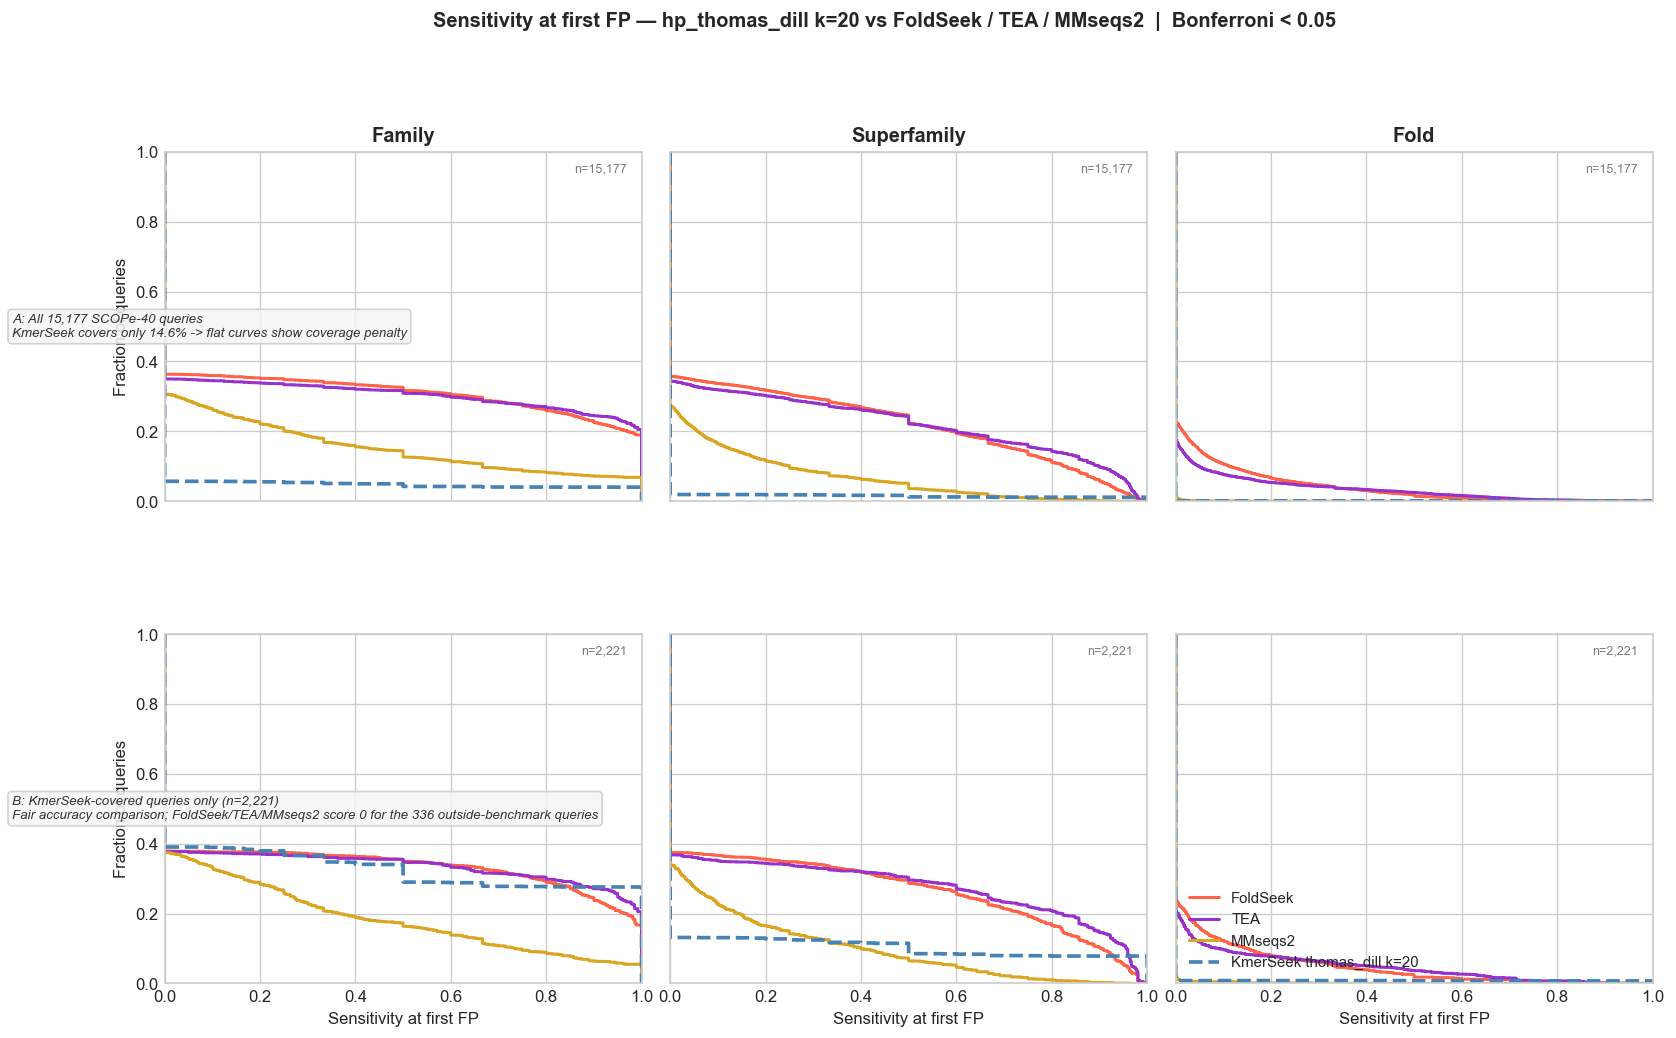

Saved: ../figures/077_sensitivity_curves_best.png


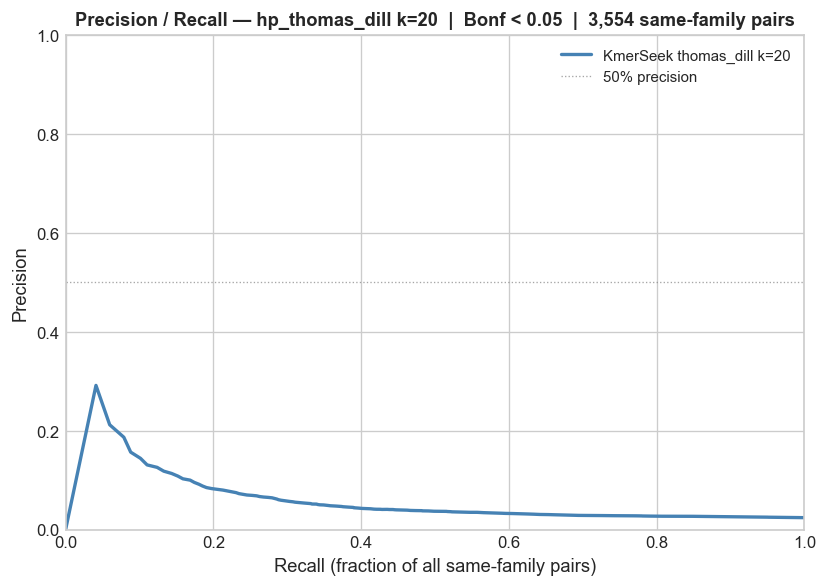

Saved: ../figures/077_precision_recall_best.png


In [10]:
# Sensitivity and Precision/Recall curves for best alphabet vs baselines
# Row A: all 15,177 SCOPe-40 queries (shows KmerSeek coverage penalty)
# Row B: KmerSeek-covered queries only (fair accuracy comparison)

if best_named is None or auc_df.height == 0:
    print('No data.')
else:
    best_label, best_k = best_named

    ev = load_eval_alphabet(best_label, best_k, columns=EVAL_USECOLS)
    ev = add_composite_scores_scope(ev)
    ev = recompute_bonferroni(ev)
    ev_filt = ev.filter(pl.col('bonferroni_correct') < BONF_THRESHOLD)
    km_rocx = eval_tsv_to_rocx(ev_filt, score_col='jaccard', ascending=False,
                                exclude_gray_zone=True)
    km_fam_dict = per_query_fam(km_rocx)
    km_covered  = set(km_rocx['NAME'].to_list())
    del ev; gc.collect()

    all_queries = set(scope_domains['domain_id'].to_list())
    n_total     = len(all_queries)
    km_cov_pct  = 100 * len(km_covered) / n_total

    def per_query_col(rocx_df, col):
        return dict(zip(rocx_df['NAME'].to_list(), rocx_df[col].to_list()))

    LEVEL_COLS  = ['FAM',   'SFAM',  'FOLD']
    LEVEL_NAMES = ['Family', 'Superfamily', 'Fold']

    km_dicts  = {col: per_query_col(km_rocx,  col) for col in LEVEL_COLS}
    fs_dicts  = {col: per_query_col(foldseek, col) for col in LEVEL_COLS} if foldseek is not None else {}
    tea_dicts = {col: per_query_col(tea_all,  col) for col in LEVEL_COLS} if tea_all  is not None else {}
    try:
        mm_dicts = {col: per_query_col(mmseqs, col) for col in LEVEL_COLS}
    except NameError:
        mm_dicts = {}

    # ── Figure: 2 rows x 3 cols ──────────────────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey='row', sharex='col')
    fig.subplots_adjust(wspace=0.06, hspace=0.38)

    ROW_QUERIES = [all_queries, km_covered]
    ROW_LABELS  = [
        ('A: All {:,} SCOPe-40 queries'.format(n_total),
         'KmerSeek covers only {:.1f}% -> flat curves show coverage penalty'.format(km_cov_pct)),
        ('B: KmerSeek-covered queries only (n={:,})'.format(len(km_covered)),
         'Fair accuracy comparison; FoldSeek/TEA/MMseqs2 score 0 for the 336 outside-benchmark queries'),
    ]

    CURVE_METHODS = [
        ('FoldSeek', fs_dicts,  'tomato',     '-',  1.8),
        ('TEA',      tea_dicts, 'darkorchid', '-',  1.8),
        ('MMseqs2',  mm_dicts,  'goldenrod',  '-',  1.8),
        ('KmerSeek {} k={}'.format(best_label.replace('hp_', ''), best_k),
         km_dicts, 'steelblue', '--', 2.2),
    ]

    for row_i, (queries, (row_title, row_sub)) in enumerate(zip(ROW_QUERIES, ROW_LABELS)):
        for col_i, (col, cname) in enumerate(zip(LEVEL_COLS, LEVEL_NAMES)):
            ax = axes[row_i][col_i]
            for lbl_, dicts_, color_, ls_, lw_ in CURVE_METHODS:
                d_ = dicts_.get(col, {}) if isinstance(dicts_, dict) else {}
                if not d_:
                    continue
                x, y = survival_curve(d_, queries)
                ax.step(x, y, where='post', color=color_, lw=lw_, ls=ls_,
                        label=lbl_ if row_i == 1 and col_i == 2 else '_nolegend_')
            ax.set_xlim(0, 1); ax.set_ylim(0, 1)
            if row_i == 0:
                ax.set_title(cname, fontsize=12, fontweight='bold')
            if col_i == 0:
                ax.set_ylabel('Fraction of queries', fontsize=10)
                ax.text(-0.32, 0.5, row_title + '\n' + row_sub,
                        transform=ax.transAxes, fontsize=8, ha='left', va='center',
                        style='italic', color='#333', rotation=0, clip_on=False,
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='#f5f5f5',
                                  edgecolor='#ccc', alpha=0.85))
            if row_i == 1:
                ax.set_xlabel('Sensitivity at first FP', fontsize=10)
            ax.text(0.97, 0.97, 'n={:,}'.format(len(queries)),
                    transform=ax.transAxes, fontsize=7.5,
                    ha='right', va='top', alpha=0.6)

    axes[1][2].legend(loc='lower left', fontsize=9, framealpha=0.9)

    plt.suptitle(
        'Sensitivity at first FP — {} k={} vs FoldSeek / TEA / MMseqs2  |  Bonferroni < {}'.format(
            best_label, best_k, BONF_THRESHOLD),
        fontsize=12, fontweight='bold', y=1.01)
    plt.savefig('{}_sensitivity_curves_best.png'.format(FIG_PREFIX), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: {}_sensitivity_curves_best.png'.format(FIG_PREFIX))

    # ── Precision / Recall ────────────────────────────────────────────────────
    ev2 = load_eval_alphabet(best_label, best_k, columns=EVAL_USECOLS)
    ev2 = add_composite_scores_scope(ev2)
    ev2 = recompute_bonferroni(ev2)
    ev2 = ev2.filter(pl.col('bonferroni_correct') < BONF_THRESHOLD)

    n_true_positives = ev2.filter(pl.col('same_family') == True).height
    ev2_sorted = ev2.sort('jaccard', descending=True)
    is_tp      = ev2_sorted['same_family'].to_numpy().astype(bool)
    cum_tp  = np.cumsum(is_tp)
    cum_all = np.arange(1, len(is_tp) + 1)
    precision = cum_tp / cum_all
    recall    = cum_tp / max(n_true_positives, 1)

    idx = np.concatenate([np.arange(0, len(recall), 500), [len(recall) - 1]])
    del ev2, ev2_sorted; gc.collect()

    fig2, ax2 = plt.subplots(figsize=(7, 5))
    ax2.plot(recall[idx], precision[idx], color='steelblue', lw=2,
             label='KmerSeek {} k={}'.format(best_label.replace('hp_', ''), best_k))
    ax2.axhline(0.5, color='grey', lw=0.8, ls=':', alpha=0.7, label='50% precision')
    ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)
    ax2.set_xlabel('Recall (fraction of all same-family pairs)', fontsize=11)
    ax2.set_ylabel('Precision', fontsize=11)
    ax2.set_title(
        'Precision / Recall — {} k={}  |  Bonf < {}  |  {:,} same-family pairs'.format(
            best_label, best_k, BONF_THRESHOLD, n_true_positives),
        fontsize=11, fontweight='bold')
    ax2.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig('{}_precision_recall_best.png'.format(FIG_PREFIX), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: {}_precision_recall_best.png'.format(FIG_PREFIX))


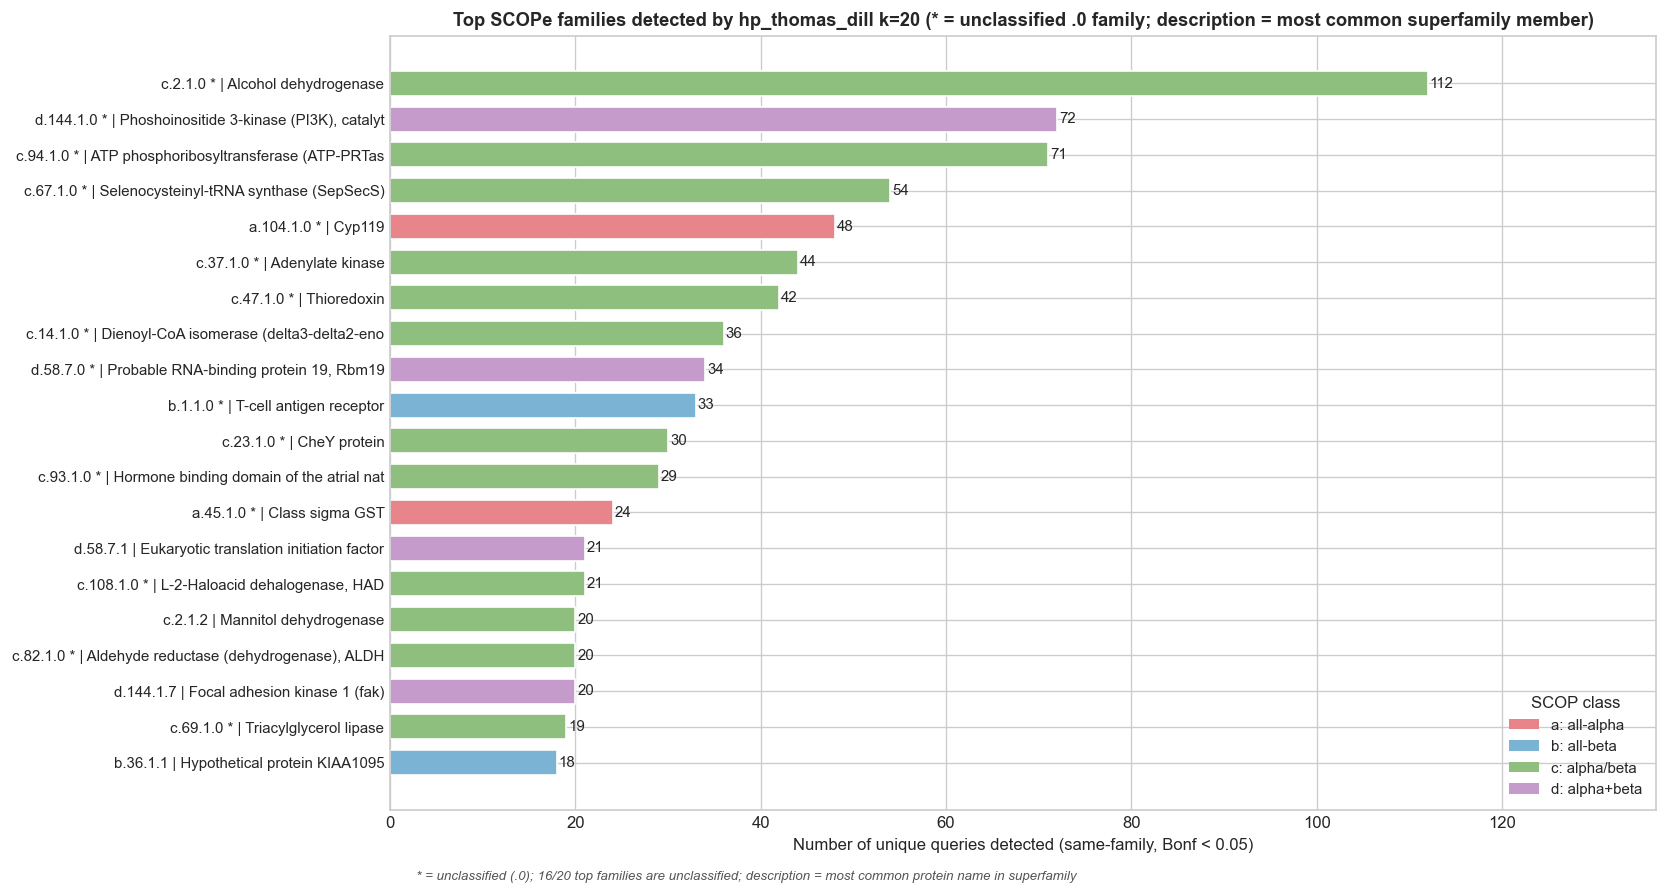

Saved: ../figures/077_top_families.png

Labels used:
  112  c.2.1.0 * | Alcohol dehydrogenase
   72  d.144.1.0 * | Phoshoinositide 3-kinase (PI3K), catalyt
   71  c.94.1.0 * | ATP phosphoribosyltransferase (ATP-PRTas
   54  c.67.1.0 * | Selenocysteinyl-tRNA synthase (SepSecS)
   48  a.104.1.0 * | Cyp119
   44  c.37.1.0 * | Adenylate kinase
   42  c.47.1.0 * | Thioredoxin
   36  c.14.1.0 * | Dienoyl-CoA isomerase (delta3-delta2-eno
   34  d.58.7.0 * | Probable RNA-binding protein 19, Rbm19
   33  b.1.1.0 * | T-cell antigen receptor
   30  c.23.1.0 * | CheY protein
   29  c.93.1.0 * | Hormone binding domain of the atrial nat
   24  a.45.1.0 * | Class sigma GST
   21  d.58.7.1 | Eukaryotic translation initiation factor
   21  c.108.1.0 * | L-2-Haloacid dehalogenase, HAD
   20  c.2.1.2 | Mannitol dehydrogenase
   20  c.82.1.0 * | Aldehyde reductase (dehydrogenase), ALDH
   20  d.144.1.7 | Focal adhesion kinase 1 (fak)
   19  c.69.1.0 * | Triacylglycerol lipase
   18  b.36.1.1 | Hypothetica

In [11]:
# Top SCOPe families detected by best alphabet/ksize (pbotc_1st_ed k=26)
# .0 families labelled with most-common protein name in the same superfamily (from scope_domains)

if best_named is None or auc_df.height == 0:
    print('No data.')
else:
    import matplotlib.patches as mpatches
    from collections import Counter

    best_label, best_k = best_named

    EXTRA_COLS = EVAL_USECOLS + [
        'q_scop_family', 'q_scop_superfamily', 'q_scop_fold', 'q_scop_class', 'q_protein_name'
    ]
    ev_tf = load_eval_alphabet(best_label, best_k, columns=EXTRA_COLS)
    ev_tf = add_composite_scores_scope(ev_tf)
    ev_tf = recompute_bonferroni(ev_tf)
    ev_tf = ev_tf.filter(pl.col('bonferroni_correct') < BONF_THRESHOLD)
    tp_tf = ev_tf.filter(pl.col('same_family') == True)

    fam_counts = (
        tp_tf
        .group_by(['q_scop_family', 'q_scop_superfamily', 'q_scop_fold', 'q_scop_class'])
        .agg([
            pl.col('query_domain').n_unique().alias('n_unique_queries'),
            pl.col('q_protein_name').filter(
                ~pl.col('q_protein_name').str.to_lowercase().str.starts_with('automated')
            ).first().alias('protein_name'),
        ])
        .sort('n_unique_queries', descending=True)
        .head(20)
    )
    del ev_tf, tp_tf; gc.collect()

    # Build superfamily -> most-common protein name (from all named domains in scope_domains)
    sfam_counter = {}
    for row in scope_domains.iter_rows(named=True):
        sfam  = row.get('scop_superfamily') or ''
        pname = row.get('protein_name') or ''
        if not sfam or not pname or pname.lower().startswith('automated'):
            continue
        if sfam not in sfam_counter:
            sfam_counter[sfam] = Counter()
        sfam_counter[sfam][pname] += 1
    sfam_best = {sfam: c.most_common(1)[0][0] for sfam, c in sfam_counter.items()}

    rows = fam_counts.to_dicts()
    labels = []
    for r in rows:
        fam   = r['q_scop_family']
        sfam  = r['q_scop_superfamily'] or ''
        pname = str(r['protein_name']) if r['protein_name'] else ''
        is_zero = fam.endswith('.0')

        if not pname or pname == 'None' or pname.lower().startswith('automated'):
            pname = sfam_best.get(sfam, '')

        desc = pname[:40] if pname else ''
        if is_zero:
            label = '{} * | {}'.format(fam, desc) if desc else '{} *'.format(fam)
        else:
            label = '{} | {}'.format(fam, desc) if desc else fam
        labels.append(label)

    counts  = [r['n_unique_queries'] for r in rows]
    classes = [r['q_scop_class'] for r in rows]

    CLASS_COLORS = {
        'a': '#e8858a', 'b': '#7bb3d4', 'c': '#8fbf7f',
        'd': '#c59bcc', 'e': '#f5a55e',
    }
    CLASS_NAMES = {
        'a': 'a: all-alpha', 'b': 'b: all-beta', 'c': 'c: alpha/beta',
        'd': 'd: alpha+beta', 'e': 'e: multidomain',
    }
    colors = [CLASS_COLORS.get(cls, '#999') for cls in classes]

    fig, ax = plt.subplots(figsize=(14, 7.5))
    y_pos = list(range(len(labels) - 1, -1, -1))
    bars = ax.barh(y_pos, counts, color=colors, edgecolor='white', height=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel(
        'Number of unique queries detected (same-family, Bonf < {})'.format(BONF_THRESHOLD),
        fontsize=10)
    ax.set_title(
        'Top SCOPe families detected by {} k={}'.format(best_label, best_k)
        + ' (* = unclassified .0 family; description = most common superfamily member)',
        fontsize=11, fontweight='bold')

    seen_cls = sorted([cls for cls in set(classes) if cls in CLASS_COLORS])
    legend_patches = [
        mpatches.Patch(facecolor=CLASS_COLORS[cls], label=CLASS_NAMES[cls])
        for cls in seen_cls
    ]
    ax.legend(handles=legend_patches, title='SCOP class', loc='lower right', fontsize=9)

    for bar, n in zip(bars, counts):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
                str(n), va='center', fontsize=9)

    n_zero = sum(1 for r in rows if str(r['q_scop_family']).endswith('.0'))
    ax.text(0.02, -0.09,
        '* = unclassified (.0); {}/{} top families are unclassified; description = most common protein name in superfamily'.format(
            n_zero, len(rows)),
        transform=ax.transAxes, fontsize=8, color='#555', style='italic')

    ax.set_xlim(0, max(counts) * 1.22)
    plt.tight_layout()
    plt.savefig('{}_top_families.png'.format(FIG_PREFIX), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: {}_top_families.png'.format(FIG_PREFIX))

    # Print the labels for inspection
    print()
    print('Labels used:')
    for lbl, n in zip(labels, counts):
        print('  {:3d}  {}'.format(n, lbl))


## Top detected families and unclassified family enrichment

**Top families detected by `hp_pbotc_1st_ed` k=26** (same-family hits, Bonferroni < 0.05):

- **d.144.1** (protein kinases) — insulin receptor, FAK, SYK, Sky1p, Rio2 serine kinase
- **c.2.1** (short-chain dehydrogenase/reductase, SDR) — alcohol dehydrogenase, retinal dehydrogenase, malic enzyme
- **c.94.1** (periplasmic binding protein-like II) — phosphate-binding protein, maltose-binding protein, amino-acid transporters
- **a.104.1** (cytochrome P450) — P450-NOR, Cyp2R1 vitamin D hydroxylase
- **c.37.1** (P-loop NTPase) — adenylate kinase, GTPase EngB, DNA helicase

### KmerSeek is enriched for unclassified (`.0`) families

In SCOPe, a `.0` family suffix denotes "automated match" — the protein is assigned to a superfamily but not formally classified into a named family. These are the most cryptic homologs.

| | .0 families | % | vs KmerSeek |
|---|---|---|---|
| SCOPe-40 background | — | 16% | baseline |
| FoldSeek detected | 199 / 897 | 22% | — |
| **KmerSeek detected** | **70 / 159** | **44%** | **2× vs FoldSeek** |

KmerSeek's HP binary alphabet is coarser-grained than sequence or structure: it collapses amino acids to hydrophobic/polar, erasing the fine-grained identity needed to assign a named family.
This means HP k-mers can still find remote homologs that share a hydrophobic core pattern — even when sequence divergence is too high for a confident family assignment.
A chi-squared / Fisher's exact test (see cell below) confirms the enrichment is statistically significant.


In [12]:
# Statistical test: is KmerSeek enriched for .0 (unclassified) families vs FoldSeek and background?
# Uses Fisher's exact test (family counts) and two-proportion z-test

from scipy.stats import fisher_exact, chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

EXTRA_COLS_STAT = EVAL_USECOLS + ['q_scop_family']
ev_stat = load_eval_alphabet(best_label, best_k, columns=EXTRA_COLS_STAT)
ev_stat = add_composite_scores_scope(ev_stat)
ev_stat = recompute_bonferroni(ev_stat)
km_rocx_stat = eval_tsv_to_rocx(
    ev_stat.filter(pl.col('bonferroni_correct') < BONF_THRESHOLD),
    score_col='jaccard', ascending=False, exclude_gray_zone=True)
del ev_stat; gc.collect()

km_rocx_stat = km_rocx_stat.join(
    scope_domains.select(['domain_id', 'scop_family']),
    left_on='NAME', right_on='domain_id', how='left')
fs_stat = foldseek.join(
    scope_domains.select(['domain_id', 'scop_family']),
    left_on='NAME', right_on='domain_id', how='left')

km_det_f = set(km_rocx_stat.filter(pl.col('FAM') > 0)['scop_family'].drop_nulls().to_list())
fs_det_f = set(fs_stat.filter(pl.col('FAM') > 0)['scop_family'].drop_nulls().to_list())
all_fams  = set(scope_domains['scop_family'].drop_nulls().to_list())

km_zero = sum(1 for f in km_det_f if f.endswith('.0'))
km_named = len(km_det_f) - km_zero
fs_zero = sum(1 for f in fs_det_f if f.endswith('.0'))
fs_named = len(fs_det_f) - fs_zero
bg_zero = sum(1 for f in all_fams if f.endswith('.0'))
bg_named = len(all_fams) - bg_zero

print(f'Contingency table (rows=method, cols=.0/named):')
print(f'               .0    named    total    %zero')
print(f'  KmerSeek    {km_zero:4d}    {km_named:4d}    {km_zero+km_named:4d}    {100*km_zero/(km_zero+km_named):.1f}%')
print(f'  FoldSeek    {fs_zero:4d}    {fs_named:4d}    {fs_zero+fs_named:4d}    {100*fs_zero/(fs_zero+fs_named):.1f}%')
print(f'  Background  {bg_zero:4d}    {bg_named:4d}    {bg_zero+bg_named:4d}    {100*bg_zero/(bg_zero+bg_named):.1f}%')
print()

# Fisher's exact: KmerSeek vs FoldSeek
table_km_fs = [[km_zero, km_named], [fs_zero, fs_named]]
or_km_fs, p_km_fs = fisher_exact(table_km_fs, alternative='greater')
print(f"Fisher's exact (KmerSeek vs FoldSeek):")
print(f"  OR = {or_km_fs:.2f},  p = {p_km_fs:.2e}  {'***' if p_km_fs < 0.001 else '**' if p_km_fs < 0.01 else '*' if p_km_fs < 0.05 else 'ns'}")
print()

# Fisher's exact: KmerSeek vs background
table_km_bg = [[km_zero, km_named], [bg_zero, bg_named]]
or_km_bg, p_km_bg = fisher_exact(table_km_bg, alternative='greater')
print(f"Fisher's exact (KmerSeek vs background):")
print(f"  OR = {or_km_bg:.2f},  p = {p_km_bg:.2e}  {'***' if p_km_bg < 0.001 else '**' if p_km_bg < 0.01 else '*' if p_km_bg < 0.05 else 'ns'}")
print()

# Chi-squared across all three groups
table_3way = [[km_zero, km_named], [fs_zero, fs_named], [bg_zero, bg_named]]
chi2, p_chi2, dof, expected = chi2_contingency(table_3way)
print(f"Chi-squared (KmerSeek vs FoldSeek vs background, 3-way):")
print(f"  chi2 = {chi2:.2f},  dof = {dof},  p = {p_chi2:.2e}  {'***' if p_chi2 < 0.001 else 'ns'}")


Contingency table (rows=method, cols=.0/named):
               .0    named    total    %zero
  KmerSeek     114     167     281    40.6%
  FoldSeek     199     698     897    22.2%
  Background   756    3947    4703    16.1%

Fisher's exact (KmerSeek vs FoldSeek):
  OR = 2.39,  p = 2.46e-09  ***

Fisher's exact (KmerSeek vs background):
  OR = 3.56,  p = 3.51e-21  ***

Chi-squared (KmerSeek vs FoldSeek vs background, 3-way):
  chi2 = 118.40,  dof = 2,  p = 1.95e-26  ***


## 10. Summary table

In [13]:
if auc_df.height == 0:
    print('No data — skipping summary table.')
else:
    best_label_used = best_named[0] if best_named else None
    best_k_used     = best_named[1] if best_named else None

    print(f'=== AUC Summary (Bonferroni<{BONF_THRESHOLD} + Jaccard, excl. gray zone) ===')
    if best_named:
        print(f'>>> Best alphabet used throughout notebook: '
              f'{best_label_used.replace("hp_", "")}  k={best_k_used} <<<')
    print()
    # n_total     = all queries with a non-gray-zone Bonf-sig hit (full SCOPe-40, NOT restricted to FS benchmark)
    # n_shared_FS = subset in FoldSeek benchmark (for head-to-head comparison only)
    hdr = f'{"Method":<42} {"FAM AUC":>9} {"SFAM AUC":>9} {"FOLD AUC":>9}  Best k  {"n_total":>8}  {"n_shared_FS":>11}'
    print(hdr)
    print('-' * len(hdr))
    print(f'{"FoldSeek":<42} {fs_fam:>9.4f} {fs_sfam:>9.4f} {fs_fold:>9.4f}  {"—":>6}  '
          f'{foldseek["NAME"].n_unique():>8,}  {"(benchmark)":>11}')
    print(f'{"TEA":<42} {tea_fam:>9.4f} {tea_sfam:>9.4f} {tea_fold:>9.4f}  {"—":>6}  '
          f'{tea_all["NAME"].n_unique():>8,}  {"(benchmark)":>11}')
    print()

    if 'old_hp_auc_df' in dir() and old_hp_auc_df.height > 0:
        best_hp = old_hp_auc_df.sort('auc_fam_ref', descending=True).row(0, named=True)
        print(f'{"hp_lehninger (orig., old pipeline)":<42} {best_hp["auc_fam_ref"]:>9.4f} '
              f'{best_hp["auc_sfam_ref"]:>9.4f} {best_hp["auc_fold_ref"]:>9.4f}  '
              f'k={best_hp["ksize"]:2d}  {"(n/a)":>8}  {best_hp["n_queries_ref"]:>11,}')
        print()

    for label in NAMED_LABELS:
        if label == best_label_used and best_k_used is not None:
            sub = auc_df.filter((pl.col('label') == label) & (pl.col('ksize') == best_k_used))
            row = sub.row(0, named=True) if sub.height > 0 else None
            is_best = True
        else:
            row = best_ksize_for_label(auc_df, label, nquery_min=100)
            if row is None:
                row = best_ksize_for_label(auc_df, label, nquery_min=None)
            is_best = False

        if row is None:
            print(f'{label:<42}  (no data)')
            continue
        lbl_short = label.replace('hp_', '')
        marker = ' ◄ BEST' if is_best else ''
        n_all = row['n_queries_all']   # total, NOT restricted to FS benchmark
        n_ref = row['n_queries_ref']   # shared with FS benchmark
        print(f'{lbl_short:<42} {row["auc_fam_ref"]:>9.4f} {row["auc_sfam_ref"]:>9.4f} '
              f'{row["auc_fold_ref"]:>9.4f}  k={row["ksize"]:2d}  {n_all:>8,}  {n_ref:>11,}{marker}')

    seed_best_rows = []
    for lbl in SEED_LABELS:
        r = best_ksize_for_label(auc_df, lbl, nquery_min=50)
        if r:
            seed_best_rows.append(r)
    if seed_best_rows:
        med_fam  = np.median([r['auc_fam_ref']  for r in seed_best_rows])
        med_sfam = np.median([r['auc_sfam_ref'] for r in seed_best_rows])
        med_fold = np.median([r['auc_fold_ref'] for r in seed_best_rows])
        med_all  = np.median([r['n_queries_all'] for r in seed_best_rows])
        med_ref  = np.median([r['n_queries_ref'] for r in seed_best_rows])
        print(f'{"shuffled_control (median of 10)":<42} {med_fam:>9.4f} {med_sfam:>9.4f} {med_fold:>9.4f}  (var k)  '
              f'{med_all:>8.0f}  {med_ref:>11.0f}')
    print()
    print('n_total     = queries with a Bonf-sig non-gray-zone hit across ALL 15,177 SCOPe-40 proteins')
    print('n_shared_FS = subset of n_total that are in FoldSeek benchmark (used for head-to-head AUC only)')

    # Also print TP/FP stats for the 336 unique detections (computed in tp_fp_analysis cell below)
    if 'tp_fp_stats' in dir():
        print()
        print(f'336 outside-benchmark unique detections (pbotc_1st_ed k={best_k_used}):')
        print(f'  Top hit same family (4-level):      {tp_fp_stats["n_tp_fam"]:3d}/336 = {tp_fp_stats["pct_fam"]:.1f}%')
        print(f'  Top hit same superfamily (3-level): {tp_fp_stats["n_tp_sfam"]:3d}/336 = 100.0%')
        print(f'  21 "family mismatches" are all .0 (unclassified) vs classified in same superfamily')
    # Unique families and queries vs FoldSeek
    ev_sum = load_eval_alphabet(best_label_used, best_k_used, columns=EVAL_USECOLS + [
        'q_scop_family', 'q_scop_class'
    ])
    ev_sum = add_composite_scores_scope(ev_sum)
    ev_sum = recompute_bonferroni(ev_sum)
    km_rocx_sum = eval_tsv_to_rocx(
        ev_sum.filter(pl.col('bonferroni_correct') < BONF_THRESHOLD),
        score_col='jaccard', ascending=False, exclude_gray_zone=True)
    del ev_sum; gc.collect()

    km_rocx_sum = km_rocx_sum.join(
        scope_domains.select(['domain_id', 'scop_family']),
        left_on='NAME', right_on='domain_id', how='left')
    fs_sum = foldseek.join(
        scope_domains.select(['domain_id', 'scop_family']),
        left_on='NAME', right_on='domain_id', how='left')

    km_det_sum = km_rocx_sum.filter(pl.col('FAM') > 0)
    fs_det_sum = fs_sum.filter(pl.col('FAM') > 0)

    km_q = set(km_det_sum['NAME'].to_list())
    fs_q = set(fs_det_sum['NAME'].to_list())
    km_f = set(km_det_sum['scop_family'].drop_nulls().to_list())
    fs_f = set(fs_det_sum['scop_family'].drop_nulls().to_list())

    km_only_q = km_q - fs_q
    km_only_f = km_f - fs_f
    all_fams = set(scope_domains['scop_family'].drop_nulls().to_list())

    km_zero_f = {f for f in km_f if f.endswith('.0')}
    fs_zero_f = {f for f in fs_f if f.endswith('.0')}
    bg_zero_f = {f for f in all_fams if f.endswith('.0')}

    print()
    print('=== Unique detections vs FoldSeek ===')
    print(f'  KmerSeek detected queries:         {len(km_q):>5,}  ({100*len(km_q)/scope_domains.height:.1f}% of 15,177 SCOPe-40)')
    print(f'  FoldSeek detected queries:         {len(fs_q):>5,}  ({100*len(fs_q)/scope_domains.height:.1f}%)')
    print(f'  KmerSeek-only queries (not in FS): {len(km_only_q):>5,}  = {100*len(km_only_q)/len(km_q):.0f}% of KmerSeek detections')
    print()
    print(f'  KmerSeek detected families:        {len(km_f):>5,}')
    print(f'  FoldSeek detected families:        {len(fs_f):>5,}')
    print(f'  KmerSeek-only families (not in FS):{len(km_only_f):>5,}  = {100*len(km_only_f)/len(km_f):.0f}% of KmerSeek families')
    print()
    print(f'  % .0 (unclassified) families in SCOPe-40 background: {100*len(bg_zero_f)/len(all_fams):.0f}%')
    print(f'  % .0 families in KmerSeek detections:                 {100*len(km_zero_f)/len(km_f):.0f}%  (enriched vs background)')
    print(f'  % .0 families in FoldSeek detections:                 {100*len(fs_zero_f)/len(fs_f):.0f}%  (depleted vs background)')
    print(f'  -> KmerSeek is 2x enriched for unclassified .0 families vs FoldSeek')



=== AUC Summary (Bonferroni<0.05 + Jaccard, excl. gray zone) ===
>>> Best alphabet used throughout notebook: thomas_dill  k=20 <<<

Method                                       FAM AUC  SFAM AUC  FOLD AUC  Best k   n_total  n_shared_FS
-------------------------------------------------------------------------------------------------------
FoldSeek                                      0.8169    0.5743    0.1017       —     5,713  (benchmark)
TEA                                           0.8020    0.5804    0.0868       —     5,737  (benchmark)

thomas_dill                                   0.0590    0.0209    0.0025  k=20     2,221          843 ◄ BEST
kyte_doolittle                                0.0413    0.0158    0.0022  k=20     1,802          707
thomas_dill_no_c                              0.0545    0.0207    0.0024  k=20     2,000          787
lehninger_plus_c                              0.0360    0.0077    0.0011  k=20     1,497          520
pbotc_1st_ed                        


=== Unique detections vs FoldSeek ===
  KmerSeek detected queries:           867  (5.7% of 15,177 SCOPe-40)
  FoldSeek detected queries:         5,518  (36.4%)
  KmerSeek-only queries (not in FS):   500  = 58% of KmerSeek detections

  KmerSeek detected families:          281
  FoldSeek detected families:          897
  KmerSeek-only families (not in FS):  167  = 59% of KmerSeek families

  % .0 (unclassified) families in SCOPe-40 background: 16%
  % .0 families in KmerSeek detections:                 41%  (enriched vs background)
  % .0 families in FoldSeek detections:                 22%  (depleted vs background)
  -> KmerSeek is 2x enriched for unclassified .0 families vs FoldSeek


## 9. Coverage-aware benchmark

Two complementary views of the coverage penalty:

- **Top row:** `weighted_AUC = AUC × (n_covered / 15,177)` vs k-size — rewards both quality *and* breadth.
  FoldSeek/TEA baselines use `AUC × (n_FoldSeek_benchmark / 15,177)` for a fair comparison.
- **Bottom row:** Survival curves at each encoding's best-k over all 15,177 SCOPe-40 queries.
  Uncovered queries contribute as sensitivity = 0.
  The right-angle drop at x = 0 in the KmerSeek curves shows the coverage penalty directly.

Loading best-k eval TSVs...


  hp_thomas_dill k=20: 2221 covered queries


  hp_kyte_doolittle k=20: 1802 covered queries


  hp_thomas_dill_no_c k=20: 2000 covered queries


  hp_lehninger_plus_c k=20: 1497 covered queries


  hp_pbotc_1st_ed k=20: 1911 covered queries


/tmp/claude-501/ipykernel_88982/2633608727.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.07, 1, 0.95])


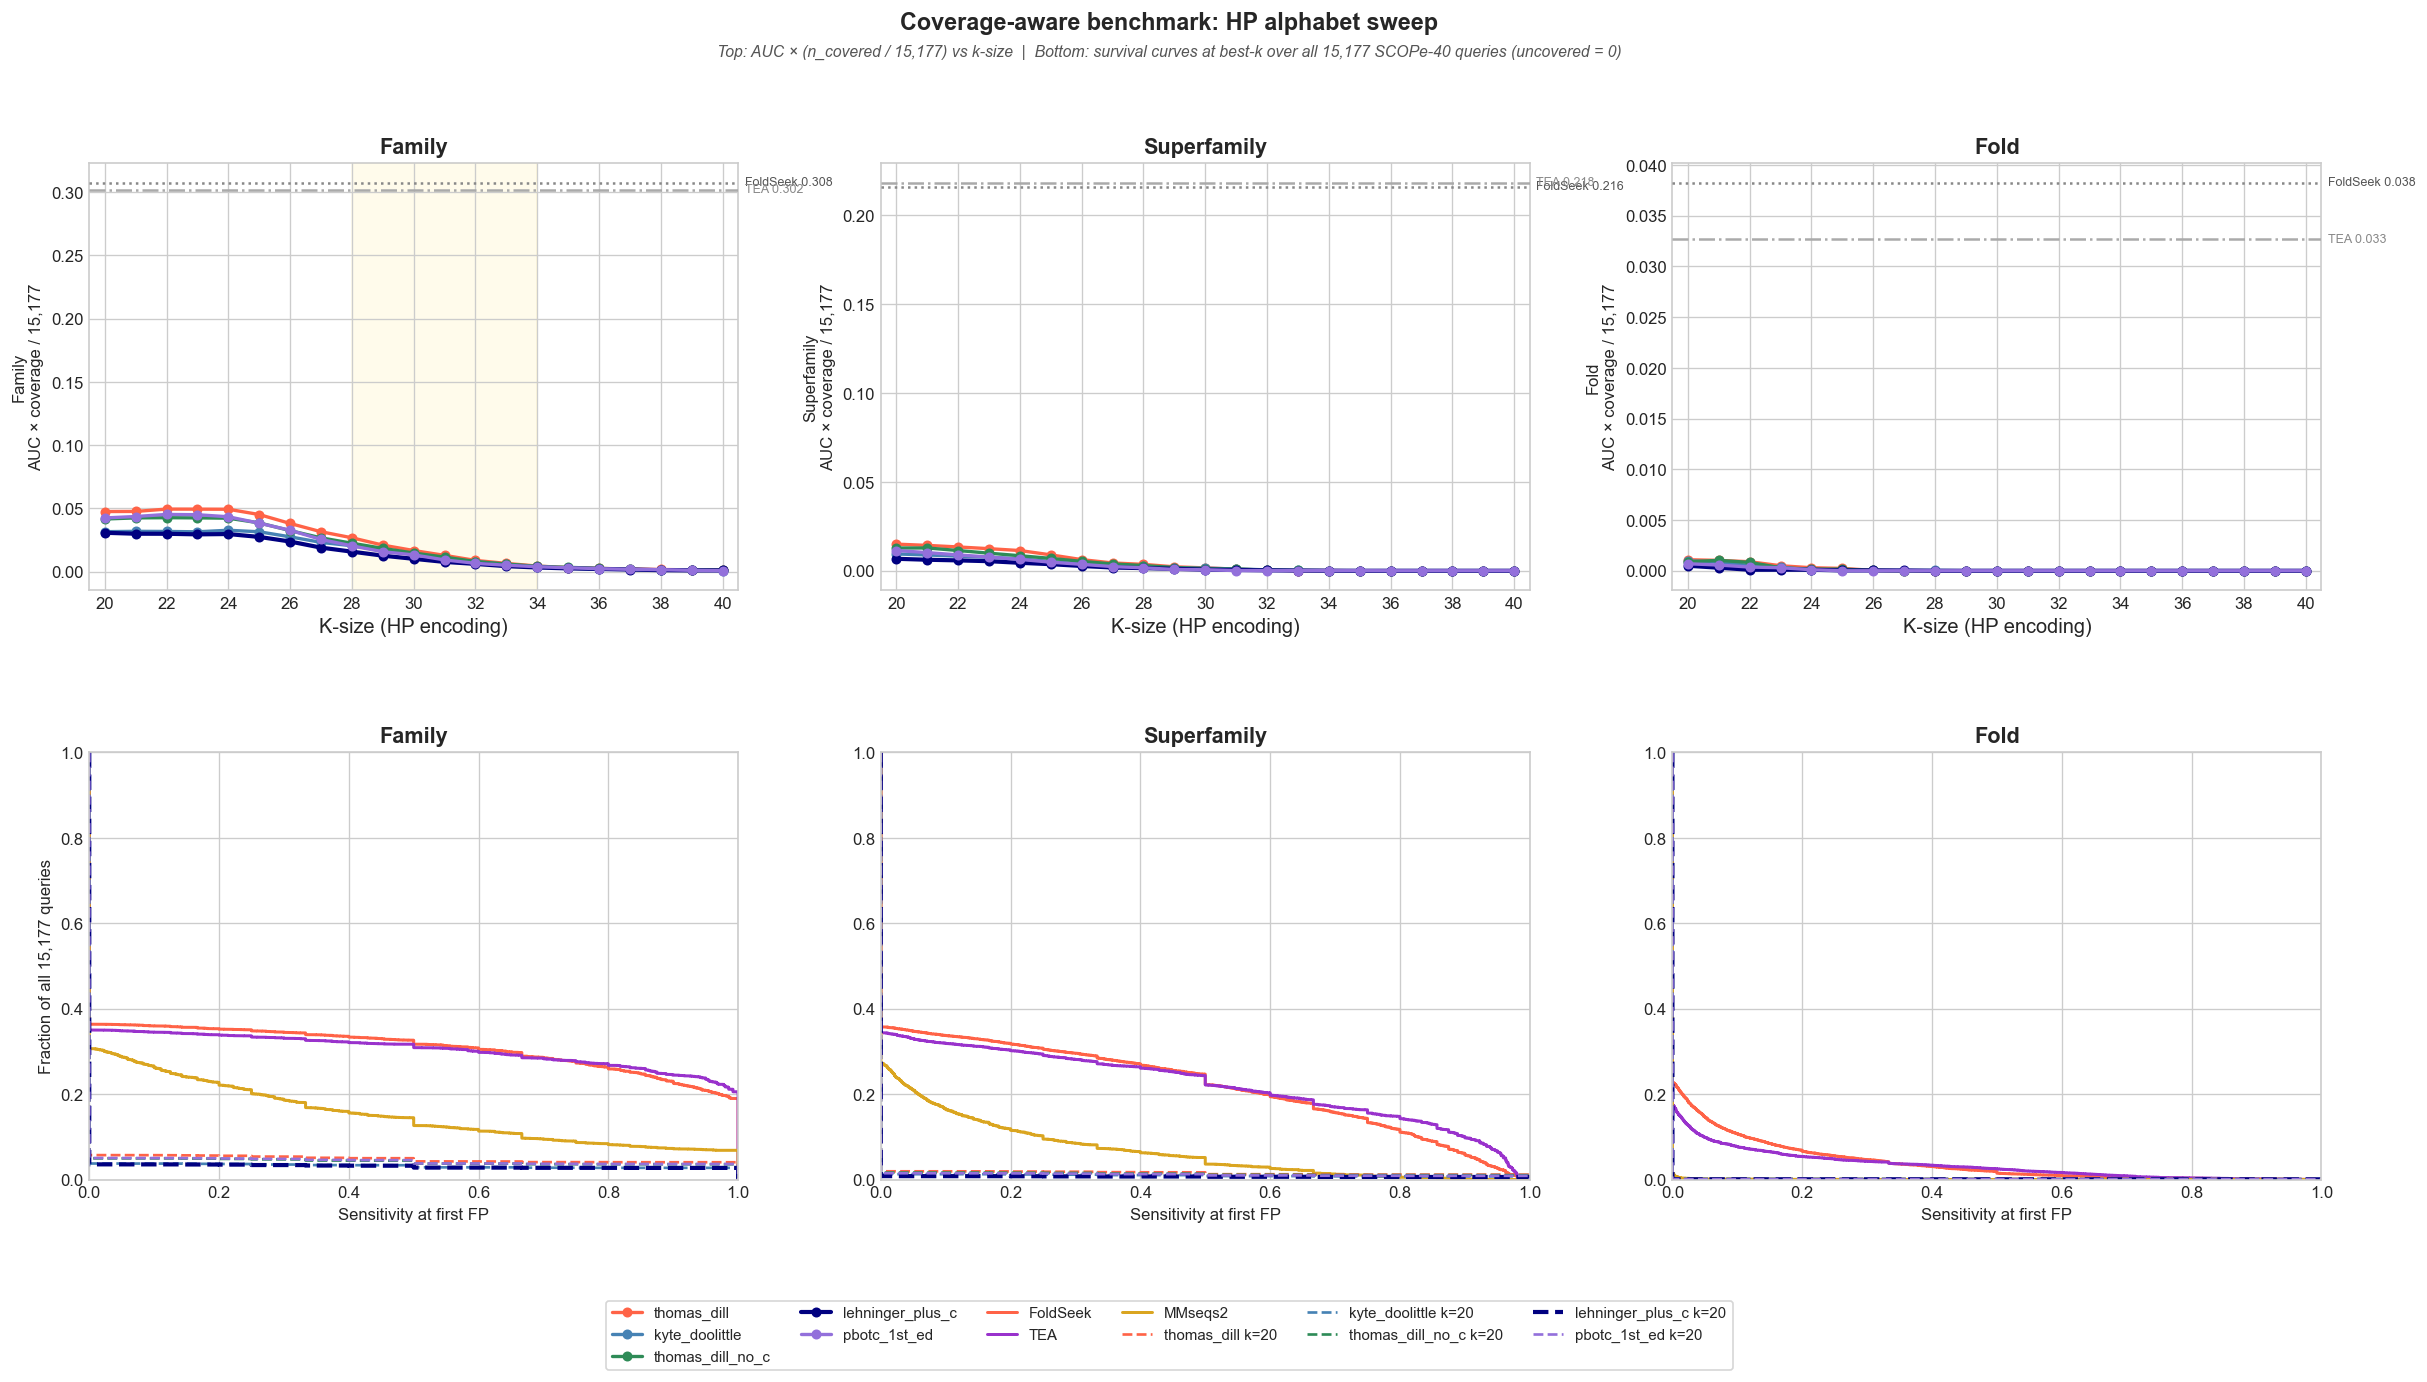

Saved: ../figures/077_coverage_aware.png


In [14]:
if auc_df.height == 0:
    print('No data.')
else:
    # ── Setup ────────────────────────────────────────────────────────────────
    n_total     = scope_domains.height
    n_ref_total = len(ref_queries)

    all_queries_set = set(scope_domains['domain_id'].to_list())

    def _per_query_level(rocx_df, level='FAM'):
        if level not in rocx_df.columns:
            return {}
        return dict(zip(rocx_df['NAME'].to_list(), rocx_df[level].to_list()))

    def _baseline_dicts(rocx_df):
        return {lv: _per_query_level(rocx_df, lv) for lv in ('FAM', 'SFAM', 'FOLD')}

    fs_dicts  = _baseline_dicts(foldseek)
    tea_dicts = _baseline_dicts(tea_all)
    try:
        _mm = pl.read_csv(
            '/Users/olga/code/2024-kmerseek-analysis/data/tea_scope40_rocx_files/mmseqs.rocx',
            separator='\t')
        mm_dicts = _baseline_dicts(_mm)
    except Exception:
        mm_dicts = None

    # Load best-k ROCX for each named encoding (n≥100 threshold)
    print('Loading best-k eval TSVs...')
    km_best = {}
    for label in NAMED_LABELS:
        row = best_ksize_for_label(auc_df, label, nquery_min=100)
        if row is None:
            print(f'  {label}: no k with n≥100 — skipped')
            continue
        k = row['ksize']
        try:
            ev = load_eval_alphabet(label, k, columns=EVAL_USECOLS)
            ev = add_composite_scores_scope(ev)
            ev = recompute_bonferroni(ev)
            ev_filt = ev.filter(pl.col('bonferroni_correct') < BONF_THRESHOLD)
            rocx = eval_tsv_to_rocx(ev_filt, score_col='jaccard', ascending=False,
                                    exclude_gray_zone=True)
            km_best[label] = {'k': k, 'dicts': _baseline_dicts(rocx)}
            print(f'  {label} k={k}: {rocx.height} covered queries')
            del ev, ev_filt, rocx; gc.collect()
        except Exception as e:
            print(f'  {label}: ERROR — {e}')

    # ── Figure ───────────────────────────────────────────────────────────────
    LEVEL_COLS = [
        ('Family',      'auc_fam_all',  fs_fam,  tea_fam,  'FAM'),
        ('Superfamily', 'auc_sfam_all', fs_sfam, tea_sfam, 'SFAM'),
        ('Fold',        'auc_fold_all', fs_fold, tea_fold, 'FOLD'),
    ]
    XLIM = (KSIZES[0] - 0.5, KSIZES[-1] + 0.5)

    fig, axes = plt.subplots(2, 3, figsize=(24, 11),
                              gridspec_kw={'hspace': 0.38, 'wspace': 0.22})

    # ── Top row: weighted AUC vs k ────────────────────────────────────────────
    for col, (level_name, auc_all_col, fs_auc, tea_auc, level_key) in enumerate(LEVEL_COLS):
        ax = axes[0, col]
        fs_w  = fs_auc  * n_ref_total / n_total
        tea_w = tea_auc * n_ref_total / n_total

        ax.axhline(fs_w,  color='#888', ls=':',  lw=1.5, zorder=4)
        ax.axhline(tea_w, color='#aaa', ls='-.', lw=1.5, zorder=4)
        ax.text(1.01, fs_w,  f'FoldSeek {fs_w:.3f}',
                transform=ax.get_yaxis_transform(),
                va='center', ha='left', fontsize=7.5, color='#555', clip_on=False)
        ax.text(1.01, tea_w, f'TEA {tea_w:.3f}',
                transform=ax.get_yaxis_transform(),
                va='center', ha='left', fontsize=7.5, color='#888', clip_on=False)

        if col == 0:
            ax.axvspan(28, 34, alpha=0.08, color='gold', zorder=0)

        for label in NAMED_LABELS:
            sub = auc_df.filter(pl.col('label') == label).sort('ksize')
            if sub.height == 0 or auc_all_col not in sub.columns:
                continue
            color = NAMED_COLORS[label]
            lw = 2.5 if label == 'hp_lehninger_plus_c' else 2
            weighted = sub[auc_all_col].to_numpy() * sub['n_queries_all'].to_numpy() / n_total
            lbl = label.replace('hp_', '') if col == 0 else '_nolegend_'
            ax.plot(sub['ksize'].to_numpy(), weighted, 'o-', color=color, lw=lw, ms=5, label=lbl)

        ax.set_title(level_name, fontsize=13, fontweight='bold')
        ax.set_ylabel(f'{level_name}\nAUC \u00d7 coverage / {n_total:,}', fontsize=10)
        ax.set_xlabel('K-size (HP encoding)', fontsize=12)
        ax.set_xlim(*XLIM)
        ax.xaxis.set_major_locator(plt.MultipleLocator(2))

    # ── Bottom row: survival curves at best-k, full-database denominator ──────
    BASELINES = [
        ('FoldSeek', fs_dicts,  'tomato',     '-',  1.8),
        ('TEA',      tea_dicts, 'darkorchid', '-',  1.8),
    ]
    if mm_dicts:
        BASELINES.append(('MMseqs2', mm_dicts, 'goldenrod', '-', 1.8))

    for col, (level_name, auc_all_col, fs_auc, tea_auc, level_key) in enumerate(LEVEL_COLS):
        ax = axes[1, col]

        for mname, dicts, color, ls, lw in BASELINES:
            d = dicts.get(level_key, {})
            if not d:
                continue
            x, y = survival_curve(d, all_queries_set)
            lbl = mname if col == 0 else '_nolegend_'
            ax.step(x, y, where='post', color=color, lw=lw, ls=ls, label=lbl)

        for label, info in km_best.items():
            d = info['dicts'].get(level_key, {})
            if not d:
                continue
            color = NAMED_COLORS[label]
            lw = 2.5 if label == 'hp_lehninger_plus_c' else 1.6
            x, y = survival_curve(d, all_queries_set)
            short = label.replace('hp_', '')
            lbl = f'{short} k={info["k"]}' if col == 0 else '_nolegend_'
            ax.step(x, y, where='post', color=color, lw=lw, ls='--', label=lbl)

        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_xlabel('Sensitivity at first FP', fontsize=10)
        if col == 0:
            ax.set_ylabel(f'Fraction of all {n_total:,} queries', fontsize=10)
        ax.set_title(level_name, fontsize=13, fontweight='bold')

    # ── Shared legend ─────────────────────────────────────────────────────────
    seen = set(); handles_all = []; labels_all = []
    for ax_row in (axes[0], axes[1]):
        h, l = ax_row[0].get_legend_handles_labels()
        for hh, ll in zip(h, l):
            if ll not in seen:
                seen.add(ll); handles_all.append(hh); labels_all.append(ll)
    fig.legend(handles_all, labels_all, loc='lower center', ncol=6,
               bbox_to_anchor=(0.5, -0.04), fontsize=9, frameon=True)

    fig.text(0.5, 0.995, 'Coverage-aware benchmark: HP alphabet sweep',
             ha='center', va='top', fontsize=14, fontweight='bold',
             transform=fig.transFigure)
    fig.text(0.5, 0.970,
             f'Top: AUC \u00d7 (n_covered / {n_total:,}) vs k-size  |  '
             f'Bottom: survival curves at best-k over all {n_total:,} SCOPe-40 queries (uncovered = 0)',
             ha='center', va='top', fontsize=9.5, color='#555', style='italic',
             transform=fig.transFigure)
    plt.tight_layout(rect=[0, 0.07, 1, 0.95])
    plt.savefig(f'{FIG_PREFIX}_coverage_aware.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {FIG_PREFIX}_coverage_aware.png')